In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots, features
import pandas as pd

sp500_components = dataset.SP500.load_historical()

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [3]:
apple = dataset.YahooFinance.get_ticker_data_incremental("AAPL", save_csv=True)

plots.summarize_df(apple)

Loading existing data for AAPL from AAPL.csv
Fetching new data for AAPL since 2026-04-10
Updated AAPL with new data
Saved data for AAPL to AAPL.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 11423 entries, 1980-12-12 05:00:00+00:00 to 2026-04-10 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          11423 non-null  float64
 1   High          11423 non-null  float64
 2   Low           11423 non-null  float64
 3   Close         11423 non-null  float64
 4   Adj Close     11423 non-null  float64
 5   Volume        11423 non-null  int64  
 6   Dividends     11423 non-null  float64
 7   Stock Splits  11423 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 803.2+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,11423.00000000,11423.00000000,11423.00000000,11423.00000000,11423.00000000,11423.00000000,11423.00000000,11423.00000000
mean,30.25021464,30.57676348,29.94054644,30.27151036,29.31985092,308166674.40252125,0.00088099,0.00148823
std,60.78470956,61.43379779,60.18036829,60.83337376,60.29916318,333028100.95799971,0.01314736,0.08209239
min,0.04966500,0.04966500,0.04910700,0.04910700,0.03760944,0.00000000,0.00000000,0.00000000
25%,0.30530150,0.31185250,0.29910699,0.30524600,0.24742643,105240800.00000000,0.00000000,0.00000000
50%,0.60937500,0.62165201,0.59821397,0.61160702,0.49704421,197120000.00000000,0.00000000,0.00000000
75%,24.60625076,24.82535744,24.34499931,24.56375027,21.95862389,388264800.00000000,0.00000000,0.00000000
max,286.20001221,288.61999512,283.29998779,286.19000244,285.92245483,7421640800.00000000,0.26000000,7.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12 05:00:00+00:00,0.12834799,0.12890600,0.12834799,0.12834799,0.09829751,469033600,0.00000000,0.00000000
1980-12-15 05:00:00+00:00,0.12221000,0.12221000,0.12165200,0.12165200,0.09316928,175884800,0.00000000,0.00000000
2026-04-09 04:00:00+00:00,259.00000000,261.11999512,256.07000732,260.48999023,260.48999023,28121600,0.00000000,0.00000000
2026-04-10 00:00:00-04:00,259.98001099,262.19000244,259.01998901,260.48001099,260.48001099,31259500,0.00000000,0.00000000


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [4]:
plots.YahooFinance.show_last_split(apple)

,Open,Adj Close,Dividends,Stock Splits
Date,,,,
2020-08-28 04:00:00+00:00,126.01249695,121.17153168,0.00000000,0.00000000
2020-08-31 04:00:00+00:00,127.58000183,125.28071594,0.00000000,4.00000000
2020-09-01 04:00:00+00:00,132.75999451,130.27098083,0.00000000,0.00000000


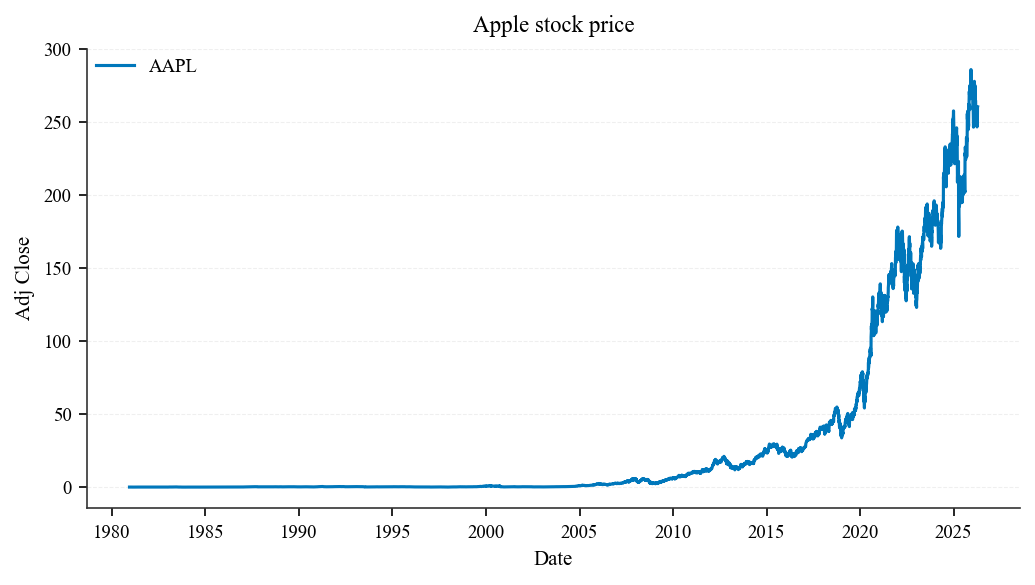

,AAPL
Date,
1980-12-12,0.09829751
1980-12-15,0.09316928
1980-12-16,0.08633082
1980-12-17,0.08846761
1980-12-18,0.09103247
...,...
2026-04-06,258.85998535
2026-04-07,253.50000000
2026-04-08,258.89999390


In [5]:
plots.YahooFinance.show_chart(apple, "AAPL", title="Apple stock price", hide_col=True)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [6]:
SP500 = dataset.YahooFinance.get_ticker_data_incremental("^GSPC", save_csv=True)
SP500TR = dataset.YahooFinance.get_ticker_data_incremental("^SP500TR", save_csv=True)
ETF = dataset.YahooFinance.get_ticker_data_incremental("CSPX.L", save_csv=True)

plots.summarize_df(SP500)
plots.summarize_df(SP500TR)
plots.summarize_df(ETF)

Loading existing data for ^GSPC from ^GSPC.csv
Fetching new data for ^GSPC since 2026-04-10
Updated ^GSPC with new data
Saved data for ^GSPC to ^GSPC.csv
Loading existing data for ^SP500TR from ^SP500TR.csv
Fetching new data for ^SP500TR since 2026-04-10
Updated ^SP500TR with new data
Saved data for ^SP500TR to ^SP500TR.csv
Loading existing data for CSPX.L from CSPX.L.csv
Fetching new data for CSPX.L since 2026-04-12
Updated CSPX.L with new data
Saved data for CSPX.L to CSPX.L.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 24685 entries, 1927-12-30 05:00:00+00:00 to 2026-04-10 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24685 non-null  float64
 1   High          24685 non-null  float64
 2   Low           24685 non-null  float64
 3   Close         24685 non-null  float64
 4   Adj Close     24685 non-null  float64
 5   Volume        24685 non-null  int64  
 6   Dividends 

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000
mean,731.47342437,735.67470527,726.99484303,731.61894740,731.61894740,974752488.96090746,0.00000000,0.00000000
std,1255.54775441,1262.18588944,1248.35469980,1255.74260201,1255.74260201,1692395882.77580976,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,24.95999908,1600000.00000000,0.00000000,0.00000000
50%,103.62999725,104.44999695,102.80000305,103.62000275,103.62000275,22370000.00000000,0.00000000,0.00000000
75%,1093.94995117,1099.66003418,1084.90002441,1093.67004395,1093.67004395,1189900000.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 9640 entries, 1988-01-04 05:00:00+00:00 to 2026-04-10 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          9640 non-null   float64
 1   High          9640 non-null   float64
 2   Low           9640 non-null   float64
 3   Close         9640 non-null   float64
 4   Adj Close     9640 non-null   float64
 5   Volume        9640 non-null   int64  
 6   Dividends     9640 non-null   float64
 7   Stock Splits  9640 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 677.8+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,9640.00000000,9640.00000000,9640.00000000,9640.00000000,9640.00000000,9640.00000000,9640.00000000,9640.00000000
mean,3295.46446325,3309.47198838,3280.42435874,3296.01638753,3296.01638753,0.00000000,0.00000000,0.00000000
std,3433.90851624,3453.33604183,3412.80558465,3434.41970119,3434.41970119,0.00000000,0.00000000,0.00000000
min,242.86999512,242.86999512,242.86999512,242.86999512,242.86999512,0.00000000,0.00000000,0.00000000
25%,1169.40994263,1169.40994263,1169.40994263,1169.40994263,1169.40994263,0.00000000,0.00000000,0.00000000
50%,1917.51000977,1920.07501221,1914.39501953,1917.51000977,1917.51000977,0.00000000,0.00000000,0.00000000
75%,4099.68249512,4113.39257812,4083.59246826,4099.27502441,4099.27502441,0.00000000,0.00000000,0.00000000
max,15580.04003906,15580.58984375,15494.28027344,15527.82031250,15527.82031250,0.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 3932 entries, 2010-09-14 23:00:00+00:00 to 2026-04-13 00:00:00+01:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           3932 non-null   float64
 1   High           3932 non-null   float64
 2   Low            3932 non-null   float64
 3   Close          3932 non-null   float64
 4   Adj Close      3932 non-null   float64
 5   Volume         3932 non-null   int64  
 6   Dividends      3932 non-null   float64
 7   Stock Splits   3932 non-null   float64
 8   Capital Gains  3932 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 307.2+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000,3932.00000000
mean,309.07794234,315.18639787,307.31335736,309.10604529,309.10604529,96996.19328586,0.00000000,0.00000000,0.00000000
std,172.99936716,183.76723046,171.93985380,173.03059464,173.03059464,118471.85765151,0.00000000,0.00000000,0.00000000
min,94.23999786,94.50000000,1.00000000,94.58499908,94.58499908,0.00000000,0.00000000,0.00000000,0.00000000
25%,176.54750061,177.38999939,175.31500626,176.35000610,176.35000610,19991.25000000,0.00000000,0.00000000,0.00000000
50%,262.80499268,263.80999756,261.44999695,262.84500122,262.84500122,73727.50000000,0.00000000,0.00000000,0.00000000
75%,428.89751434,430.81748962,426.62998962,428.56501007,428.56501007,128494.00000000,0.00000000,0.00000000,0.00000000
max,751.09002686,888.76000977,746.71417236,748.88000488,748.88000488,1665039.00000000,0.00000000,0.00000000,0.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2010-09-14 23:00:00+00:00,95.81999969,95.81999969,95.81999969,95.54000092,95.54000092,1,0.00000000,0.00000000,0.00000000
2010-09-15 23:00:00+00:00,95.54000092,95.54000092,95.54000092,95.54000092,95.54000092,0,0.00000000,0.00000000,0.00000000
2026-04-09 23:00:00+00:00,732.69000244,735.92999268,731.92999268,734.02001953,734.02001953,190766,0.00000000,0.00000000,0.00000000
2026-04-13 00:00:00+01:00,728.26000977,728.67999268,727.66998291,728.21002197,728.21002197,28815,0.00000000,0.00000000,0.00000000


Wyniki z kolumny Close i Adj Close są jednakowe.

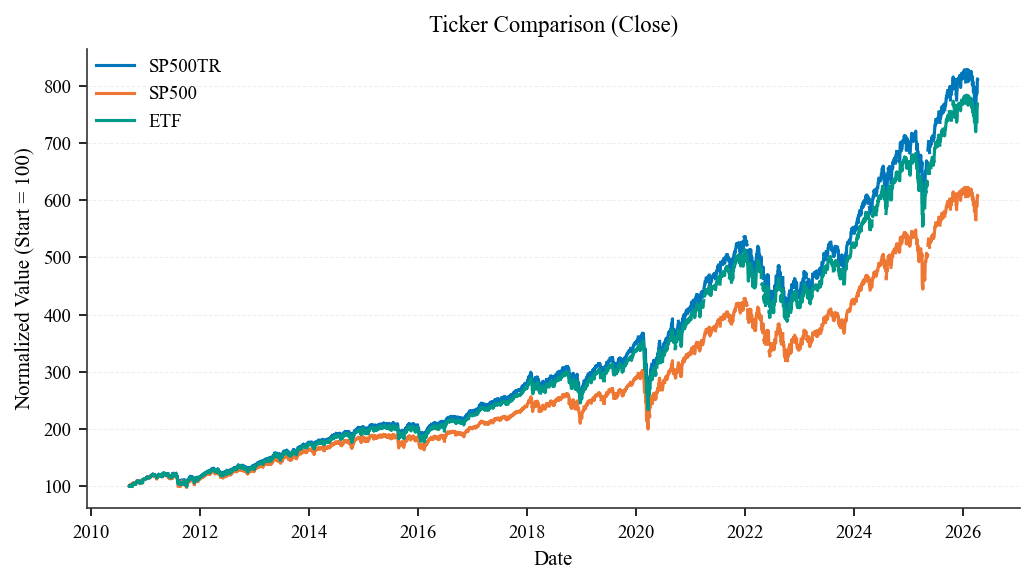

,SP500TR,SP500,ETF
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.35411389,100.00000000
2010-09-16,100.33616935,100.31755050,100.00000000
2010-09-17,100.41941377,100.40049865,NaN
2010-09-19,NaN,NaN,100.00000000
...,...,...,...
2026-04-06,787.02022833,589.76275284,737.28283197
2026-04-07,787.62479905,590.21052910,760.58191980
2026-04-08,807.37970221,605.01384411,764.61168387


In [7]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close")

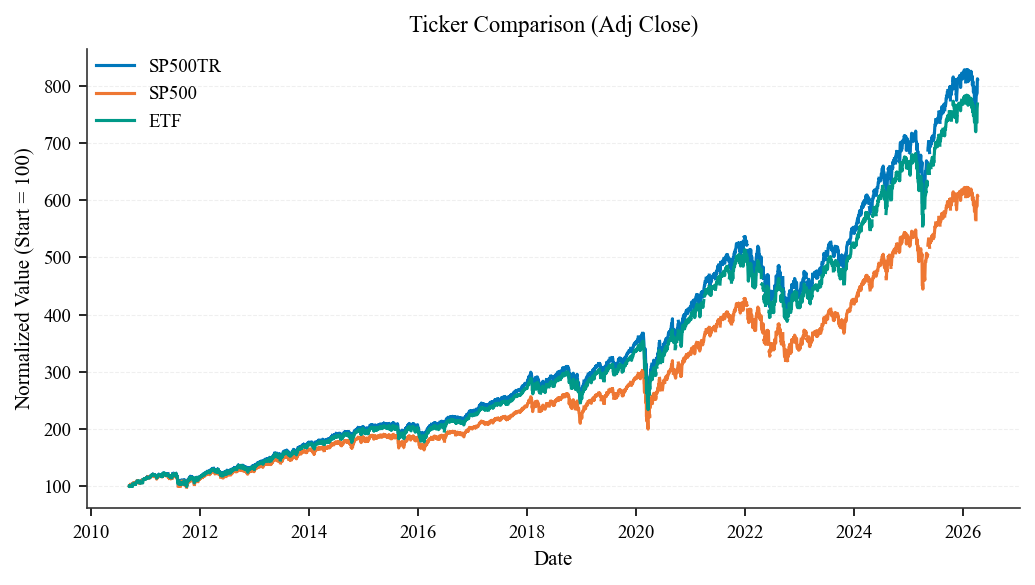

,SP500TR,SP500,ETF
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.35411389,100.00000000
2010-09-16,100.33616935,100.31755050,100.00000000
2010-09-17,100.41941377,100.40049865,NaN
2010-09-19,NaN,NaN,100.00000000
...,...,...,...
2026-04-06,787.02022833,589.76275284,737.28283197
2026-04-07,787.62479905,590.21052910,760.58191980
2026-04-08,807.37970221,605.01384411,764.61168387


In [8]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj Close")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error). Sam ETF nie jest więc wystarczający jako pełny benchmark historyczny, ponieważ jego najdłuższa porównywalna historia (dla ETF-u akumulującego dywidendy) rozpoczyna się dopiero około 2010 roku. Z tego powodu w analizie potrzebne są oba szeregi: **SP500TR** (długi horyzont historyczny i referencja total return) oraz **benchmark hybrydowy** (odwzorowanie realnych warunków inwestora poprzez uwzględnienie tracking error i wykorzystanie rzeczywistych notowań ETF tam, gdzie są dostępne).

#### Hybrydowy indeks S&P 500

W praktyce: SP500TR odpowiada za część historyczną (przed debiutem ETF), a hybryda zapewnia ciągłość serii i porównywalność wyników z realnym instrumentem inwestycyjnym.

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Loading existing benchmark from D:\Michal\Documents\Education\University\Semestr 4\Projekt indywidualny\Repo\data\processed\benchmark_2026-04-13.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 24685 entries, 1927-12-30 05:00:00+00:00 to 2026-04-10 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24685 non-null  float64
 1   High          24685 non-null  float64
 2   Low           24685 non-null  float64
 3   Close         24685 non-null  float64
 4   Adj Close     24685 non-null  float64
 5   Volume        24685 non-null  int64  
 6   Dividends     24685 non-null  float64
 7   Stock Splits  24685 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.7+ MB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000,24685.00000000
mean,731.47342437,735.67470527,726.99484303,731.61894740,731.61894740,974752488.96090746,0.00000000,0.00000000
std,1255.54775441,1262.18588944,1248.35469980,1255.74260201,1255.74260201,1692395882.77580976,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,24.95999908,1600000.00000000,0.00000000,0.00000000
50%,103.62999725,104.44999695,102.80000305,103.62000275,103.62000275,22370000.00000000,0.00000000,0.00000000
75%,1093.94995117,1099.66003418,1084.90002441,1093.67004395,1093.67004395,1189900000.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


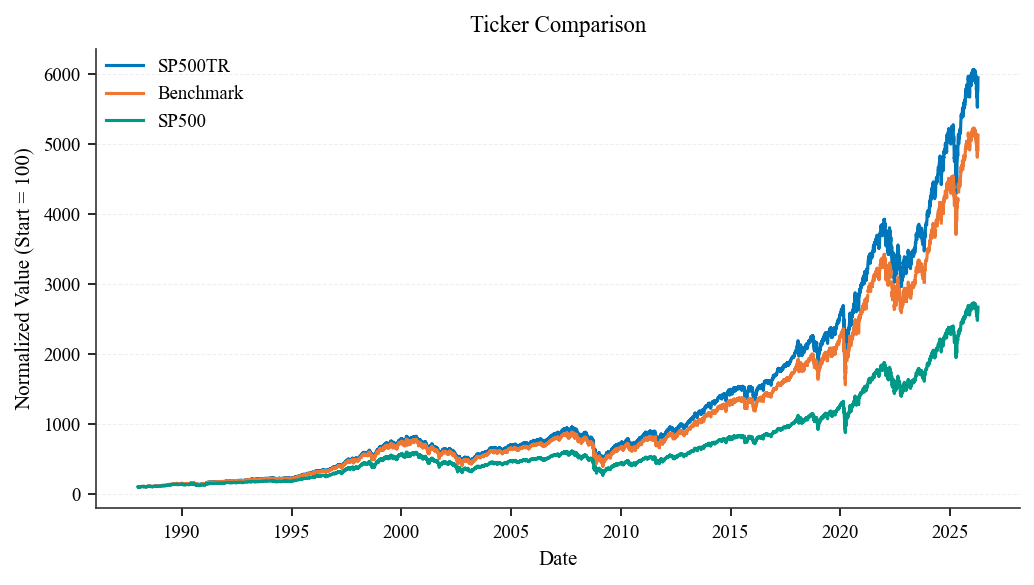

,SP500TR,Benchmark,SP500
Date,,,
1988-01-04,100.00000000,100.00000000,100.00000000
1988-01-05,101.07413488,101.07248826,101.05102853
1988-01-06,101.17569326,101.17239674,101.15261865
1988-01-07,102.02718642,102.02220005,102.00437791
1988-01-08,95.12929205,95.12309310,95.10041087
...,...,...,...
2026-04-02,5735.17726170,NaN,2571.96603837
2026-04-06,5760.99922007,4920.07683338,2583.35157266
2026-04-07,5765.42468629,5075.55760321,2585.31297747


In [9]:
benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True)

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

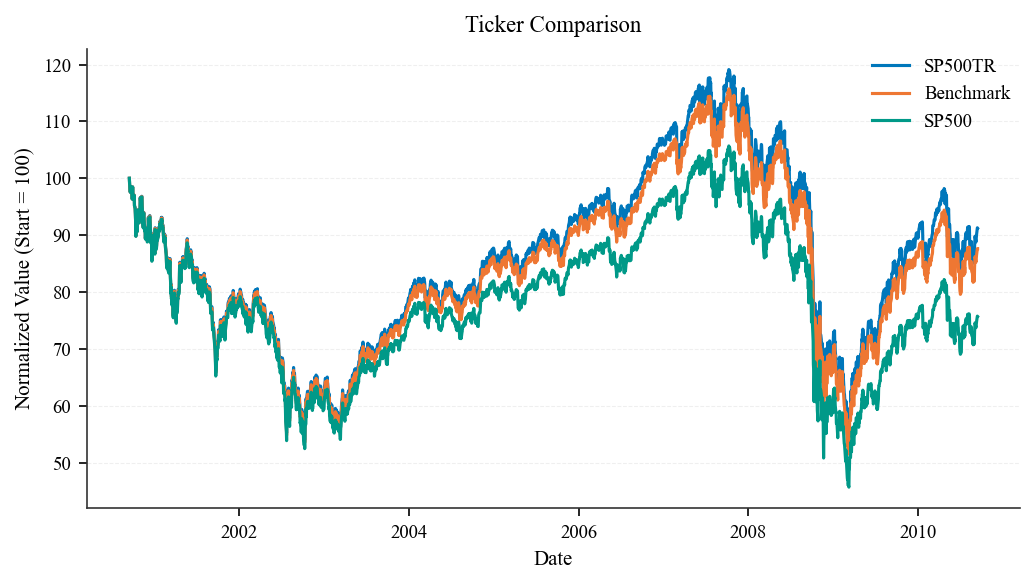

,SP500TR,Benchmark,SP500
Date,,,
2000-09-14,100.00000000,100.00000000,100.00000000
2000-09-15,98.98306332,98.98145076,98.98303453
2000-09-18,97.54650677,97.54332849,97.54468755
2000-09-19,98.58632187,98.58150367,98.58394250
2000-09-20,98.01042757,98.00404088,98.00589995
...,...,...,...
2010-09-08,89.38764760,85.80758885,74.20435276
2010-09-09,89.81993082,86.22115405,74.56292972
2010-09-10,90.25854274,86.64078078,74.92555407


In [10]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "SP500": SP500
}, hide_col=True, start_date="2000-09-14", end_date="2010-09-14")

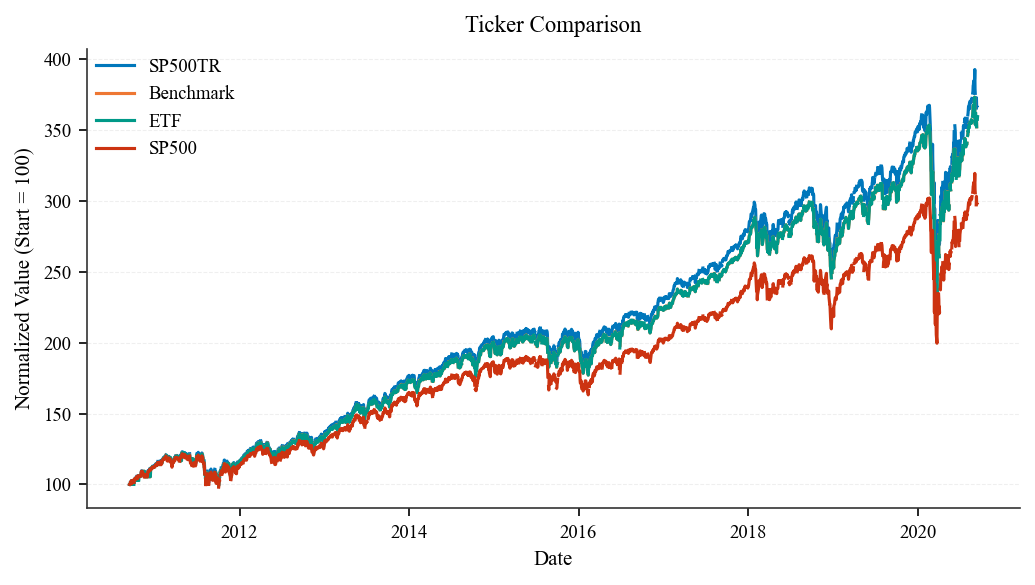

,SP500TR,Benchmark,ETF,SP500
Date,,,,
2010-09-14,100.00000000,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,NaN,100.40049865
2010-09-19,NaN,NaN,100.00000000,NaN
...,...,...,...,...
2020-09-09,372.81211299,357.89197132,357.89197132,303.18080768
2020-09-10,366.27394800,352.26081701,352.26081701,297.84943485
2020-09-11,366.48686611,NaN,NaN,298.00821010


In [11]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "ETF": ETF,
    "SP500": SP500
}, hide_col=True, start_date="2010-09-14", end_date="2020-09-14")

#### S&P 500 Equal Weighted

Dla indeksu S&P 500 Equal Weighted dostępne są następujące tickery:

- **SP500EW (^SP500EW, S&P 500 Equal Weight Index)** – indeks cenowy (*price return*) równoważonej wersji S&P 500, gdzie każda spółka ma identyczny udział niezależnie od kapitalizacji
- **ETF_EW (RSP, Invesco S&P 500 Equal Weight ETF)** – fundusz ETF replikujący indeks S&P 500 z równymi wagami, akumulujący dywidendy

Na wykresie widać, że w ostatnich latach benchmark oparty na S&P 500 przewyższał ETF na S&P 500 Equal Weight. Jednak w latach przed 2018 strategia równych wag często osiągała podobne lub lepsze wyniki. Oznacza to, że relatywna efektywność podejścia equal-weight w dużej mierze zależy od siły największych spółek w indeksie.

Loading existing data for ^SP500EW from ^SP500EW.csv
Fetching new data for ^SP500EW since 2026-04-10
Updated ^SP500EW with new data
Saved data for ^SP500EW to ^SP500EW.csv
Loading existing data for RSP from RSP.csv
Fetching new data for RSP since 2026-04-10
Updated RSP with new data
Saved data for RSP to RSP.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 4849 entries, 2006-12-08 05:00:00+00:00 to 2026-04-10 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4849 non-null   float64
 1   High          4849 non-null   float64
 2   Low           4849 non-null   float64
 3   Close         4849 non-null   float64
 4   Adj Close     4849 non-null   float64
 5   Volume        4849 non-null   int64  
 6   Dividends     4849 non-null   float64
 7   Stock Splits  4849 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 340.9+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,4849.00000000,4849.00000000,4849.00000000,4849.00000000,4849.00000000,4849.00000000,4849.00000000,4849.00000000
mean,3801.87975269,3825.70303225,3777.44544242,3803.13242818,3803.13242818,0.78366674,0.00000000,0.00000000
std,1919.39963413,1929.81297521,1909.72576442,1920.16301123,1920.16301123,54.57044616,0.00000000,0.00000000
min,824.01000977,849.15997314,810.59997559,824.01000977,824.01000977,0.00000000,0.00000000,0.00000000
25%,2025.82995605,2035.98999023,2013.51000977,2026.17004395,2026.17004395,0.00000000,0.00000000,0.00000000
50%,3342.79003906,3354.03002930,3326.14990234,3343.08007812,3343.08007812,0.00000000,0.00000000,0.00000000
75%,5604.04003906,5660.66015625,5553.70019531,5606.14013672,5606.14013672,0.00000000,0.00000000,0.00000000
max,8289.28027344,8306.87988281,8219.33984375,8290.63964844,8290.63964844,3800.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 5773 entries, 2003-05-01 04:00:00+00:00 to 2026-04-10 00:00:00-04:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           5773 non-null   float64
 1   High           5773 non-null   float64
 2   Low            5773 non-null   float64
 3   Close          5773 non-null   float64
 4   Adj Close      5773 non-null   float64
 5   Volume         5773 non-null   int64  
 6   Dividends      5773 non-null   float64
 7   Stock Splits   5773 non-null   float64
 8   Capital Gains  5773 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 451.0+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,5773.00000000,5773.00000000,5773.00000000,5773.00000000,5773.00000000,5773.00000000,5773.00000000,5773.00000000,5773.00000000
mean,85.03693791,85.50391821,84.50951070,85.03834621,74.76207803,2080383.99445695,0.00540880,0.00069288,0.00000000
std,48.01154232,48.25033016,47.76699605,48.01594574,49.55195945,3722557.35231232,0.05081454,0.05264525,0.00000000
min,20.59000015,21.15999985,18.00000000,20.59000015,15.51314831,4400.00000000,0.00000000,0.00000000,0.00000000
25%,43.79999924,44.06999969,43.47999954,43.75999832,32.69214249,397900.00000000,0.00000000,0.00000000,0.00000000
50%,75.61000061,76.01000214,75.15000153,75.69000244,62.47096634,780600.00000000,0.00000000,0.00000000,0.00000000
75%,112.01000214,112.44999695,111.37999725,111.90000153,101.02808380,1985700.00000000,0.00000000,0.00000000,0.00000000
max,204.27000427,205.24000549,203.17999268,204.97000122,204.09623718,57508500.00000000,0.83100000,4.00000000,0.00000000


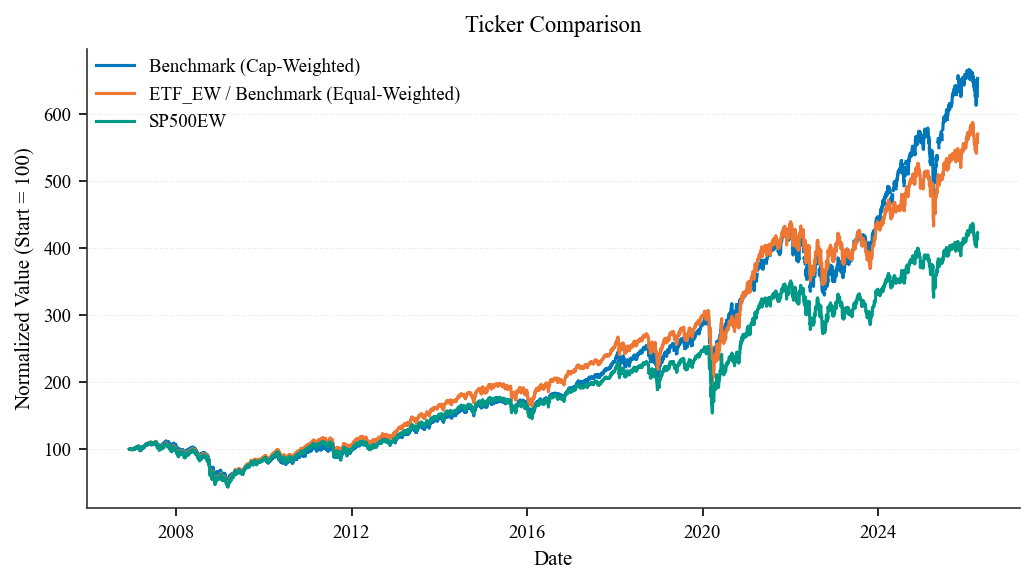

,Benchmark (Cap-Weighted),ETF_EW / Benchmark (Equal-Weighted),SP500EW
Date,,,
2006-12-08,100.00000000,100.00000000,100.00000000
2006-12-11,100.22684833,100.04197496,100.08383243
2006-12-12,100.12295563,99.89499667,99.87873422
2006-12-13,100.25674663,100.06296244,99.92091110
2006-12-14,101.13352099,100.79776597,100.74660099
...,...,...,...
2026-04-02,NaN,556.19440516,412.66951609
2026-04-06,627.21496191,558.58521972,414.42319395
2026-04-07,647.03576317,557.34662877,413.33809017


In [12]:
SP500EW = dataset.YahooFinance.get_ticker_data_incremental("^SP500EW", save_csv=True)
ETF_EW = dataset.YahooFinance.get_ticker_data_incremental("RSP", save_csv=True)

plots.summarize_df(SP500EW)
plots.summarize_df(ETF_EW)

plots.YahooFinance.compare_tickers({
    "Benchmark (Cap-Weighted)": benchmark,
    "ETF_EW / Benchmark (Equal-Weighted)": ETF_EW,
    "SP500EW": SP500EW,
}, hide_col=True)

Analogicznie do hybrydowego benchmarku dla S&P 500 ważonego kapitalizacją, można byłoby
skonstruować benchmark hybrydowy dla wersji equal-weighted, uwzględniając wpływ dywidend
zamiast błędu odwzorowania. W tym przypadku jednak `ETF_EW` (RSP) dysponuje najdłuższą
dostępną historią — sięgającą 2003 roku — a przedłużenie jej wstecz napotyka na istotne
ograniczenia: indeks dochodowy `SP500EWTR` nie jest dostępny w serwisie Yahoo Finance,
`SP500EW` obejmuje krótszy okres, natomiast zastosowanie benchmarku cap-weighted jako
substytutu zniekształciłoby charakterystykę strategii equal-weighted. Z tego powodu
`benchmark_ew` ograniczony jest do okresu dostępności `ETF_EW`, a porównanie obu podejść
prowadzone jest na wspólnym horyzoncie czasowym.

In [13]:
benchmark_ew = SP500EW

#### Uzyskanie danych pojedyńczych spółek

In [14]:
tickers = dataset.tickers_from_sp500_components(sp500_components)

yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.download(tickers, save_csv=True)
for column_name, frame in yf_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

Number of unique tickers extracted: 1194
No new trading days since 2026-04-10.
Skipping missing ticker re-download (redownload_missing_tickers=False)
Close: (16176, 1194), 1962-01-02 -> 2026-04-10
Open: (16176, 1194), 1962-01-02 -> 2026-04-10
High: (16176, 1194), 1962-01-02 -> 2026-04-10
Low: (16176, 1194), 1962-01-02 -> 2026-04-10
Volume: (16176, 1194), 1962-01-02 -> 2026-04-10
Adj_Close: (16176, 1194), 1962-01-02 -> 2026-04-10


#### Ile danych brakuje?

Na poniższym wykresie widać, że w 1996 dane z Yahoo Finance pokrywają tylko 38%. Przy wyższym pokryciu można byłoby zastosować imputację brakujących danych, jednak jest ono na tyle małe, że konieczne będzie skorzystanie z dostawców danych, pokrywających spółki, które już nie są notowane.

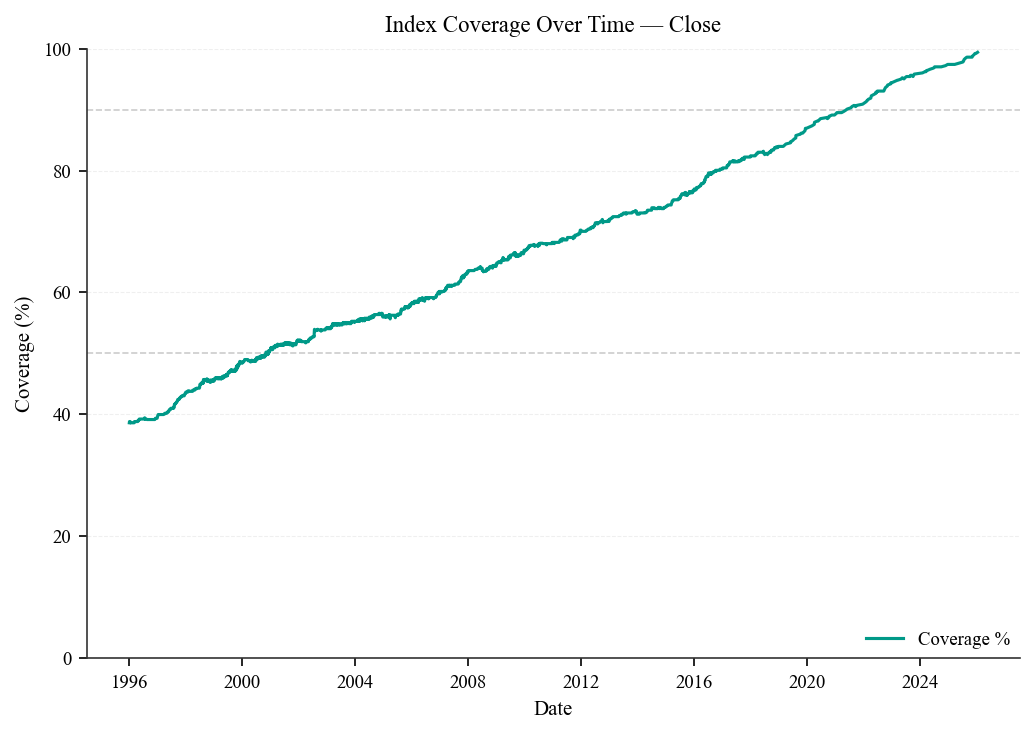

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 2705 entries, 1996-01-02 to 2026-01-14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   available       2705 non-null   int64  
 1   missing         2705 non-null   int64  
 2   not_downloaded  2705 non-null   int64  
 3   total           2705 non-null   int64  
 4   coverage_pct    2705 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 126.8 KB
None


,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,312.33456562,184.41478743,0.00000000,496.74935305,62.74024896
std,72.67110043,67.86120377,0.00000000,5.16624733,14.01065160
min,188.00000000,3.00000000,0.00000000,487.00000000,38.60369610
25%,255.00000000,133.00000000,0.00000000,494.00000000,51.51515152
50%,313.00000000,184.00000000,0.00000000,497.00000000,62.97786720
75%,364.00000000,240.00000000,0.00000000,499.00000000,73.23943662
max,500.00000000,299.00000000,0.00000000,507.00000000,99.40357853


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,188,299,0,487,38.60369610
1996-01-03,189,298,0,487,38.80903491
2025-12-22,499,4,0,503,99.20477137
2026-01-14,500,3,0,503,99.40357853


In [15]:
coverage_df = plots.coverage_over_time(yf_data, sp500_components)
plots.summarize_df(coverage_df)